In [1]:
!pip install git+https://github.com/egordudyrev/paspailleur

  Cloning https://github.com/egordudyrev/paspailleur to /tmp/pip-req-build-fa2md148
  Running command git clone --filter=blob:none --quiet https://github.com/egordudyrev/paspailleur /tmp/pip-req-build-fa2md148
  Resolved https://github.com/egordudyrev/paspailleur to commit 7566be78e73da581619c33ea42e4ebe43d74591d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


The new version `paspaileur` v0.2.0 differs a lot from the previous versions v.0.1.x and is not compatible with them.

It will be published soon to GitHub and PyPI. What is left for me to do is to write all the docstrings, the README, write more unit tests, setup GitHub actions etc...

In [2]:
import paspailleur
print(paspailleur.__version__)

0.2.0


_NB. Написано после подготовки ноутбука_

Я запустил ноутбук несклько раз как на своём компьютере, так и на Google Сolab и всё время получил один и тот же результат с одними и теми же кластерами.

Все алгоритмы, которые используются внутри ноутбука - детерминированные, поэтому в этом факте нет ничего удивительного.
С другой стороны, я помню случаи, когда результаты слегка различались от запуска к запуску. Например, мог отличаться порядок сгенерированных понятий (концептов).

Поэтому, при одних и тех же данных вы в 99.9% случаев должны получить один и тот же результат. Но, так как мы работаем с _частично_ упорядоченными множествами, иногда могут возникать небольшие несоответствия в порядке выдаваемых результатов.

# Step 0. Get the data

Табличка выгружена из Notion страницы [noml.club](https://generated-dawn-b51.notion.site/NoML-310f7075550a42a3beab57e6fc87dd56)  9 февраля.

In [3]:
import pandas as pd

df_full = pd.read_csv('NoML Seminars v. 9Feb2025.csv')
print(df_full.shape)
df_full['Дата'] = pd.to_datetime(df_full['Дата'])
df_full.index = df_full['Тип события'].map(lambda x: x[:3]) + '. ' + df_full['Дата'].dt.strftime('%d.%m.%y') # human readable indices
df_full.head(10)

(178, 17)


,Дата,Тип события,Тема,Спикеры,Tag/Topic NoML,Ключевые слова,Уровень (автор),Сложность (слушатели),Презентация и код,NoML Digest,YouTube,Дзен,Rutube,_Начинающий/продвинутый (слушатели),_Начинающий (% слушателей),# недели,Длительность~
Сем. 26.02.25,2025-02-26,Семинар,Рекомендательная система для завода по оптимиз...,Ярослав Шмулев (R77 AI),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025 Неделя №9,NaN
Сем. 19.02.25,2025-02-19,Семинар,Обучение языковой модели Cotype Nano,"Алан-Барсаг Газзаев (MTS AI, ИТМО)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025 Неделя №8,NaN
Сем. 12.02.25,2025-02-12,Семинар,Кластеризация на правилах или как найти класте...,"Егор Дудырев (НИУ ВШЭ, Университет Лотарингии)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025 Неделя №7,NaN
Сем. 05.02.25,2025-02-05,Семинар,"Интерпретируемый ИИ: рынок, теория и практичес...",Дмитрий Васильков (QuSolve),Optimization & OR,"интерпретация ML-моделей, интерпретируемый ИИ ...",Средний,NaN,%D0%92%D1%81%D0%B5%20%D0%BC%D0%B5%D1%80%D0%BE%...,https://t.me/noml_digest/775,https://youtu.be/tt7_pbVuTFU,https://dzen.ru/video/watch/67a46f0f93e7717f65...,https://rutube.ru/video/cced8e1fa113453067b476...,NaN,NaN,2025 Неделя №6,1 час 10 минут
Сем. 25.12.24,2024-12-25,Семинар,Интеллект принятия решений: почему в эру ИИ не...,"Максим Гончаров, Павел Снурницын (GlowByte)",Optimization & OR,"прогнозная, описательная и предписательная ана...",Начинающий,NaN,%D0%92%D1%81%D0%B5%20%D0%BC%D0%B5%D1%80%D0%BE%...,https://t.me/noml_digest/772,https://youtu.be/rB2XhyJByLA,https://dzen.ru/video/watch/676c5ed1bdc355605f...,https://rutube.ru/video/02e539012b6dcf2087ea97...,NaN,NaN,2024 Неделя №52,1 час 55 минут
Сем. 18.12.24,2024-12-18,Семинар,Задача Influence Maximization: открытые пробле...,Александр Гавриков (Т-Банк),GraphML,"Influence Maximization, Influence propagation ...",Продвинутый,NaN,%D0%92%D1%81%D0%B5%20%D0%BC%D0%B5%D1%80%D0%BE%...,https://t.me/noml_digest/770,https://youtu.be/DNQypHtkrM0,https://dzen.ru/video/watch/6762fbd6d101d72b7d...,https://rutube.ru/video/affae70e554e289d202ebc...,NaN,NaN,2024 Неделя №51,55 минут
Мит. 11.12.24,2024-12-11,Митап,"Математическая оптимизация: подходы, технологи...","Семён Косяченко, Александр Попков, Глеб Канин ...",Optimization & OR,"Мат. оптимизация, солверы/решатели, имитационн...",Средний,NaN,%D0%92%D1%81%D0%B5%20%D0%BC%D0%B5%D1%80%D0%BE%...,https://t.me/noml_digest/767,https://youtu.be/xqBqO6g0nic,https://dzen.ru/video/watch/675d577b5582ca25b9...,https://rutube.ru/video/ff829e2b47e80235c63cb3...,NaN,NaN,2024 Неделя №50,1 час 55 минут
Сем. 04.12.24,2024-12-04,Семинар,Вероятностное программирование для сегментации...,"Фёдор Смирнов, Максим Гончаров (GlowByte)",Causal Inference & A/B,"вероятностное программирование, структурно-вер...",Начинающий,NaN,%D0%92%D1%81%D0%B5%20%D0%BC%D0%B5%D1%80%D0%BE%...,https://t.me/noml_digest/763,https://youtu.be/O6Qq7AUeF2Y,https://dzen.ru/video/watch/6752fd835f29be2e7f...,https://rutube.ru/video/ccb48a021f14162b848a2c...,NaN,NaN,2024 Неделя №49,1 час 55 минут
Сем. 27.11.24,2024-11-27,Семинар,Causal Inference для вашего проекта: обзор кейсов,Вадим Андреевич Порватов (Сколтех),Causal Inference & A/B,"causal inference, causal discovery, байесовски...",Начинающий,NaN,%D0%92%D1%81%D0%B5%20%D0%BC%D0%B5%D1%80%D0%BE%...,https://t.me/noml_digest/759,https://youtu.be/egnhtAr0Pto,https://dzen.ru/video/watch/674750ce07fcb32f47...,https://rutube.ru/video/8dcc6ba3656d24ae2fa19f...,NaN,NaN,2024 Неделя №48,~1 час 5 минут
Сем. 20.11.24,2024-11-20,Семинар,Агенты искусственного интеллекта для поддержки...,Сергей Валерьевич Ковальчук (Университет ИТМО),NaN,decision support systems; agent-based modellin...,Начинающий,NaN,%D0%92%D1%81%D0%B5%20%D0%BC%D0%B5%D1%80%D0%BE%...,https://t.me/noml_digest/756,https://youtu.be/jk2dmo7TGSU,https://dzen.ru/video/watch/674037940d37e77647...,https://rutube.ru/video/702e9f1f60f872b9775d1c...,NaN,NaN,2024 Неделя №47,~1 час 30 минут


Добавляем новых фичей и заполняем пропуски в данных: `paspailleur` пока не умеет работать с None значениями.

In [4]:
df_full['Лет со старта'] = (df_full['Дата']-df_full['Дата'].min()).map(lambda x: x.days)/365
df_full['Tag/Topic NoML'] = df_full['Tag/Topic NoML'].fillna('<Unknown>')
df_full['Ключевые слова'] = df_full['Ключевые слова'].fillna('<Unknown>')
df_full['Спикеры'] = df_full['Спикеры'].fillna('<Unknown>')

In [5]:
import re

df = df_full[['Лет со старта', "Тип события", "Тема", "Спикеры", "Tag/Topic NoML", "Ключевые слова"]].copy()

df.loc[:, '# спикеров'] = [len(re.sub('\(.+\)', ' ', speakers).strip().split(',')) for speakers in df['Спикеры']]
df.loc[df['Спикеры']=='<Unknown>', '# спикеров'] = 0

new_tags = []
for idx, row in df.iterrows():
    tags = set()
    if re.findall('\(.+\)', row['Спикеры']):
        tags.add('Аффилированный спикер')
    new_tags.append(tags)
df.loc[:, 'Доп. теги'] = new_tags

df.head()

,Лет со старта,Тип события,Тема,Спикеры,Tag/Topic NoML,Ключевые слова,# спикеров,Доп. теги
Сем. 26.02.25,3.947945,Семинар,Рекомендательная система для завода по оптимиз...,Ярослав Шмулев (R77 AI),<Unknown>,<Unknown>,1,{Аффилированный спикер}
Сем. 19.02.25,3.928767,Семинар,Обучение языковой модели Cotype Nano,"Алан-Барсаг Газзаев (MTS AI, ИТМО)",<Unknown>,<Unknown>,1,{Аффилированный спикер}
Сем. 12.02.25,3.909589,Семинар,Кластеризация на правилах или как найти класте...,"Егор Дудырев (НИУ ВШЭ, Университет Лотарингии)",<Unknown>,<Unknown>,1,{Аффилированный спикер}
Сем. 05.02.25,3.890411,Семинар,"Интерпретируемый ИИ: рынок, теория и практичес...",Дмитрий Васильков (QuSolve),Optimization & OR,"интерпретация ML-моделей, интерпретируемый ИИ ...",1,{Аффилированный спикер}
Сем. 25.12.24,3.775342,Семинар,Интеллект принятия решений: почему в эру ИИ не...,"Максим Гончаров, Павел Снурницын (GlowByte)",Optimization & OR,"прогнозная, описательная и предписательная ана...",2,{Аффилированный спикер}


# Step 1. Initialise Pattern Structures

Инициализируем узорные структуры. Нужно описать, каким образом мы хотим обрабатывать каждый столбец в данных.

На 12 февраля, пакет может работать со следующими типами данных:
* **ItemSetPattern**, подходит для данных вроде тегов или ключевых слов:
  каждый объект (строка датасета) описывается множеством значений, и хочется узнать, какие строки описываются И тегом1 И тегом2;
* **CategorySetPattern**, подходит для категориальных данных: каждый объект описывается множеством значений, и хочется узнать, какие строки описываются ИЛИ категорией1 ИЛИ категорией 2;
* **IntervalPattern**, подходит для числовых данных: значения числового параметра каждого объекта либо попадают в какой-то интервал, либо нет;
* **NgramSetPattern**, подходит для текстовых данных: мы ищем общие последовательности слов (какой-угодно длинны) которые можно найти в описаниях разных объектов.

Также, можно создать свой собственный класс паттерна, унаследовав его от класса paspailleur.pattern_structures.pattern.Pattern и переопредилив функции пересечения паттернов `Pattern.__and__` и `Pattern.__or__`. Но это уже совсем другая история.

In [6]:
from paspailleur.pattern_structures.pattern_structure import PatternStructure
from paspailleur.pattern_structures import built_in_patterns as bip

class YearsPattern(bip.IntervalPattern):
    # Для числовых признаков, в которых может быть много уникальных значений чисел,
    # лучше задать границы дискретизации.
    # Тогда, и паттерны станет проще интерпретировать, и можно будет найти интересные стабильные интервалы
    BoundsUniverse = tuple([i+j for i in [0, 1, 2, 3] for j in [0, 0.25, 0.5, 0.75]]+[4])

class TypePattern(bip.CategorySetPattern):
    # Для категориальных признаков следует задать множество всех возможных категориальных значений
    Universe = tuple(set(df['Тип события']))

class TopicPattern(bip.NgramSetPattern):
    # Во встроенном классе NgramSetPattern, множество нграм можно задать через запятую
    # В NoML таблице, столбец Tag/Topic NoML перечисляет топики и через запятую и через амперсанд &
    # Эти данные можно предобработать как внутри класса паттерна (как сделано здесь), так и напрямую в pandas датафрейме
    def parse_string_description(self, str_descr):
        str_descr = str_descr.replace('&', ',')
        str_descr = re.sub('\s*,\s*', ',', str_descr)
        return super().parse_string_description(str_descr)

class SpeakersPattern(bip.NgramSetPattern):
    def parse_string_description(self, str_descr):
        str_descr = str_descr.replace('(', ' ( ').replace(')', ' ) ').replace(',', ' , ')
        str_descr = re.sub('\s+', ' ', str_descr)
        return super().parse_string_description(str_descr)

class TagPattern(bip.ItemSetPattern):
    # Для ItemSetPattern ничего дополнительного задавать не нужно
    ...

class KeywordsPattern(bip.ItemSetPattern):
    # Предобработка данных. Могла была быть сделана напрямую в pandas
    def parse_string_description(self, str_descr):
        str_descr = re.sub(",\s+", ",", str_descr)
        return super().parse_string_description(str_descr)


class NSpeakersPattern(bip.IntervalPattern):
    # Колчество спикеров описывается числами. Но множество значений здесь довольно ограничено. Поэтому данные можно не дискретизировать
    ...


class NewTagsPattern(bip.ItemSetPattern):
    # Тут я добавлял свои собственные теги в описание мероприятий, чтобы лучше понимать что происходит
    ...


class NoMLPattern(bip.CartesianPattern):
    # Наконец, можно создать Декартовый паттерн, который объединит в себе все столбцы в датасете в один "паттерн" для каждой строки
    DimensionTypes = {
        'Лет со старта': YearsPattern, 'Тип события': TypePattern,
        'Тема': TopicPattern, 'Спикеры': SpeakersPattern,
        'Tag/Topic NoML': TagPattern, "Ключевые слова": KeywordsPattern,
        '# спикеров': NSpeakersPattern, 'Доп. теги': NewTagsPattern,
    }

Паттерны можно создавать самому и потом сравнивать их, объединять и пересекать

In [7]:
p1 = NoMLPattern({
    'Лет со старта': [1, 2], "Тема": "Анализ Формальных Понятий",
    "Ключевые слова": "интерпретируемый ИИ, что-то ещё"
})
print(type(p1))
p1

<class '__main__.NoMLPattern'>


{'Ключевые слова': {'интерпретируемый ИИ', 'что-то ещё'}, 'Лет со старта': [1.0, 2.0], 'Тема': {'Анализ Формальных Понятий'}}

In [8]:
p2 = NoMLPattern({
    "Лет со старта": [1.5, 3], "Тема": "Анализ Ликвидности и Формальных Требований",
    "Ключевые слова": "Финансы, что-то ещё"
})
p2

{'Ключевые слова': {'Финансы', 'что-то ещё'}, 'Лет со старта': [1.5, 3.0], 'Тема': {'Анализ Ликвидности и Формальных Требований'}}

In [9]:
p3 = p1 & p2
print(p3 <= p1, p3 <= p2)
p3

True True


{'Ключевые слова': {'что-то ещё'}, 'Лет со старта': [1.0, 3.0], 'Тема': {'Анализ', 'Формальных'}}

# Step 2. Mine stable concepts

Сначала переведём pandas dataframe в формат словаря, где ключи - это (строковые) названия объектов, а значения - это паттерны для каждой строки.

Конкретно в этом ноутбуке я решил рассматривать только столбцы со Спикерами, Темой доклада и Ключевыми словами. (Числовые признаки приводят к слишком простым и очевидным кластеризациям)

In [10]:
context = {obj: NoMLPattern(row) for obj, row in df[['Спикеры', 'Тема', 'Ключевые слова']].iterrows()}

In [11]:
%%time
ps = PatternStructure()
ps.fit(context, min_atom_support=0.05)  # Подгоняем узорную структуру под контекст

Compute atomic extents:   0%|          | 0/12927 [00:00<?, ?it/s]

Compute order of patterns:   0%|          | 0/61 [00:00<?, ?it/s]

CPU times: user 1min 4s, sys: 580 ms, total: 1min 5s
Wall time: 1min 13s


Здесь атомарные паттерны - это наименьшие нетривиальные паттерны. Например, нграммы. Поэтому все остальные паттерны можно представить как объединение (eng. join, `__or__`) атомарных паттернов. Соотвественно, чем более редкие атомарные паттерны мы позволяем иметь, тем больше у нас редких паттернов в принципе.

Параметр `min_atom_support` можно задать либо через абсолютное число (т.е. минимальное количество объектов, которые должен описывать атомарный паттерн), либо через процент.

В любом случае: чем больше число, тем меньше атомарных паттернов будет в системе => тем быстрее будет всё работать. Но постарайтесь держать `min_atom_support` параметр относительно низким.

 Находим все стабильные понятия (то есть паттерны, вместе с подмножествами объектов, которые они описывают)

In [12]:
%%time
concepts = ps.mine_concepts(min_delta_stability=3, min_support=10, algorithm='gSofia', use_tqdm=True)

gSofia algorithm:   0%|          | 0/61 [00:00<?, ?it/s]

Compute intents:   0%|          | 0/72 [00:00<?, ?it/s]

CPU times: user 218 ms, sys: 3.93 ms, total: 222 ms
Wall time: 253 ms


`concepts` - это список понятий. Поэтому мы можем посмотреть на каждое такое понятие/кластер по отдельности

In [13]:
extent, intent = concepts[10]
print(f'support: {len(extent)} objects ({ps.measure_frequency(intent):.0%})')
print(f'∆-stability: {ps.measure_delta_stability(intent)}')
print(f'{intent=}')
print(f'Examples: {list(extent)[:5]}')

support: 53 objects (30%)
∆-stability: 10
intent={'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'( GlowByte', ')'}}
Examples: ['Сем. 03.08.22', 'Соз. 11.11.21', 'Под. 28.12.21', 'Сем. 26.12.23', 'Сем. 22.03.23']


При желании, кластеры можно создавать самому, ищя общие описания нескольких объектов

In [14]:
pattern = ps.intent({'Сем. 26.02.25', 'Сем. 19.02.25'})
print(pattern)
extent = ps.extent(pattern)
print(f'pattern frequency: {ps.measure_frequency(pattern):.0%}')
print('examples: ', list(extent)[:5])

{'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'(', ')', 'AI'}}
pattern frequency: 8%
examples:  ['Сем. 13.03.24', 'Сем. 26.12.23', 'Мит. 28.12.21', 'Сем. 19.02.25', 'Сем. 28.02.24']


`caspailleur` - это уже опубликованная Python библиотека, позволяющая работать с бинарными данными на манер Анализа Формальных Понятий.

К счастью, датасет с кластерами - как раз бинарный

In [15]:
import caspailleur as csp

def form_clusters_df(concepts, objects_order=list(df.index)):
    objects_order = list(df.index)
    intents = [intent for _, intent in concepts]
    extents_indices = [[objects_order.index(obj) for obj in extent] for extent, _ in concepts]

    row_names = objects_order
    col_names = [str(intent)[1:-1] for intent in intents]
    crosses_transposed = extents_indices

    clusters_df = csp.io.to_pandas((extents_indices, col_names, row_names)).T
    return clusters_df

In [16]:
clusters_df = form_clusters_df(concepts)
clusters_df.head()

,,'Ключевые слова': {'<Unknown>'},"'Спикеры': {'(', ')'}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'(', ')'}","'Спикеры': {','}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {','}",'Тема': {'и'},"'Спикеры': {'(', ')', ','}","'Спикеры': {'( GlowByte', ')'}",'Тема': {'в'},...,"'Спикеры': {'(', ')', ',', 'Максим'}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'(', ')'}, 'Тема': {'в', 'и'}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'( GlowByte )'}, 'Тема': {'в'}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'( GlowByte )'}, 'Тема': {'и'}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {', Александр'}","'Ключевые слова': {'<Unknown>'}, 'Тема': {'Feature'}","'Спикеры': {'(', ')'}, 'Тема': {'с'}","'Спикеры': {'(', ')', ','}, 'Тема': {'в'}","'Спикеры': {'( GlowByte )', ','}, 'Тема': {'и'}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {', Павел Снурницын'}"
Сем. 26.02.25,True,True,True,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Сем. 19.02.25,True,True,True,True,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
Сем. 12.02.25,True,True,True,True,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
Сем. 05.02.25,True,False,True,False,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
Сем. 25.12.24,True,False,True,False,True,False,False,True,True,True,...,True,False,False,False,False,False,False,True,False,False


# Step 3. Enumerate clusterings

Самих хороших кластеризаций может быть несметное количество. Поэтому функция для перебора кластеризаций возвращает лишь Python итератор кластеризаций. Сколько кластеризаций генерировать - вопрос бизнес задач и технических возможностей.

In [17]:
from tqdm.notebook import tqdm

In [18]:
%%time
# Функция перебора кластеризаций пока доступна лишь в backend варианте. Поэтому код может выглядеть немного страшно.
attr_extents = csp.io.to_bitarrays(clusters_df.T)  # Превращаем датасет в список bitarray'ев: каждому бинарному столбцу свой bitarray
clusterings_iterator = csp.mine_equivalence_classes.iter_minimal_broad_clusterings_via_mrgexp(
    attr_extents,  # столбцы датасета, каждый из которых описывает кластер в виде bitarray
    min_coverage=int(0.7*len(context)),  # какое минимальное количество объектов должна покрывать кластеризация (абсолютное число)
    max_length=10,  # максимальное допустимое количество кластеров в кластеризации
    min_added_coverage=10  # минимальное количество объектов которое каждый кластер должен привносить в кластеризацию. Чем больше это значение - тем меньше будут пересекаться кластеры
)

# Перебираем всевозможные кластеризации, придумывая какие-угодно условия остановки перебора
clusterings = []
for clustering_ba in tqdm(clusterings_iterator):
    if len(clusterings) > 1000:
        break

    clustering = set(clustering_ba.search(True))
    if len(clustering) <= 2:
        continue
    clusterings.append(clustering)

print(f"{len(clusterings)=}")

0it [00:00, ?it/s]

len(clusterings)=1001
CPU times: user 483 ms, sys: 9.74 ms, total: 492 ms
Wall time: 594 ms


Собираем статистику по найденным кластеризациям. Вся статистика считается на основе датафрейма с кластерами clustering_df

In [19]:
def form_clusterings_df(clusterings, clusters_df):
    clusterings_df = pd.DataFrame(index=clusterings)
    clusterings_df['size'] = [len(idxs) for idxs in clusterings_df.index]
    clusterings_df['coverage'] = [(clusters_df.iloc[:,list(idxs)].sum(1)>=1).sum() for idxs in clusterings_df.index]
    clusterings_df['intersection'] = [(clusters_df.iloc[:,list(idxs)].sum(1)>=2).sum() for idxs in clusterings_df.index]
    clusterings_df['disbalance'] = [clusters_df.iloc[:,list(idxs)].sum(0).std() for idxs in clusterings_df.index]

    # тут можете вставить какие угодно метрики для сравнения качества кластеризаций

    clusterings_df = clusterings_df.sort_values(['intersection', 'disbalance', 'coverage', 'size'],
                                                ascending=[True, True, False, False])
    return clusterings_df

In [20]:
clusterings_df = form_clusterings_df(clusterings, clusters_df)

In [21]:
clusterings_df.head()

,size,coverage,intersection,disbalance
"{25, 4, 23}",3,126,6,25.119713
"{25, 4, 20}",3,126,10,24.090109
"{25, 42, 5, 23}",4,129,12,21.173883
"{25, 23, 36, 7}",4,125,13,15.416441
"{25, 12, 20, 31}",4,124,14,10.969655


Выделяем кластеризации без пересечений (иногда такие бывают)

In [22]:
clusterings_df[clusterings_df['intersection']==0].head()

,size,coverage,intersection,disbalance


Затем начинаем смотреть получение кластеризации и искать что-нибудь интересное

In [23]:
clusters_df.iloc[:,list(clusterings_df.index[0])].mean()

,0
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'<Unknown>'}",0.162921
"'Спикеры': {','}",0.410112
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'(', ')'}, 'Тема': {'в'}",0.168539


In [24]:
clusters_df.iloc[:,list(clusterings_df.index[1])].mean()

,0
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'<Unknown>'}",0.162921
"'Спикеры': {','}",0.410112
"'Спикеры': {'(', ')'}, 'Тема': {'в'}",0.191011


In [25]:
clusters_df.iloc[:,list(clusterings_df.index[3])].mean()

,0
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'<Unknown>'}",0.162921
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'(', ')'}, 'Тема': {'в'}",0.168539
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'Максим Гончаров'}",0.123596
"'Спикеры': {'(', ')', ','}",0.320225


In [26]:
clusters_df.iloc[:,list(clusterings_df.index[4])].mean()

,0
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'<Unknown>'}",0.162921
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'(', ')', ','}",0.280899
"'Спикеры': {'(', ')'}, 'Тема': {'в'}",0.191011
'Спикеры': {'Максим Гончаров'},0.140449


In [27]:
clusters_df.iloc[:,list(clusterings_df.index[5])].mean()

,0
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'Максим Гончаров'}",0.123596
"'Спикеры': {'(', ')', ','}",0.320225
"'Ключевые слова': {'<Unknown>'}, 'Тема': {'в', 'и'}",0.095506
"'Спикеры': {'(', ')'}, 'Тема': {'на'}",0.089888
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'<Unknown>'}",0.162921


# Step 4. Find interesting clusterings

Дальше - искусство аналитики. Поиск кластеризаций, которые будут казаться интересными, нетривиальными. Которые могут что-то рассказать нам о данных

In [28]:
%%time
# уменьшим порог min_delta_stability, чтобы найти побольше кластеров
concepts2 = ps.mine_concepts(min_delta_stability=2, min_support=10, algorithm='gSofia', use_tqdm=True)
print(len(concepts2))

gSofia algorithm:   0%|          | 0/61 [00:00<?, ?it/s]

Compute intents:   0%|          | 0/89 [00:00<?, ?it/s]

89
CPU times: user 166 ms, sys: 2.97 ms, total: 169 ms
Wall time: 176 ms


In [29]:
clusters_df2 = form_clusters_df(concepts2)
clusters_df2.head()

,,'Ключевые слова': {'<Unknown>'},"'Спикеры': {'(', ')'}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'(', ')'}","'Спикеры': {','}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {','}",'Тема': {'и'},"'Спикеры': {'(', ')', ','}","'Спикеры': {'( GlowByte', ')'}",'Тема': {'в'},...,"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'( GlowByte )'}, 'Тема': {'в'}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'( GlowByte )'}, 'Тема': {'и'}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {', Александр'}","'Ключевые слова': {'<Unknown>'}, 'Тема': {'Feature'}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'( GlowByte )', ') ,', 'Александр'}","'Спикеры': {'(', ')'}, 'Тема': {'с'}","'Спикеры': {'(', ')', ','}, 'Тема': {'в'}","'Спикеры': {'( GlowByte )', ','}, 'Тема': {'и'}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {', Павел Снурницын'}","'Ключевые слова': {'<Unknown>'}, 'Тема': {'ML'}"
Сем. 26.02.25,True,True,True,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Сем. 19.02.25,True,True,True,True,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
Сем. 12.02.25,True,True,True,True,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
Сем. 05.02.25,True,False,True,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
Сем. 25.12.24,True,False,True,False,True,False,False,True,True,True,...,False,False,False,False,False,False,True,False,False,False


Ищем что-нибудь интересное в предлагаемых кластеризациях

In [30]:
%%time
attr_extents = csp.io.to_bitarrays(clusters_df2.T)
clusterings_iterator = csp.mine_equivalence_classes.iter_minimal_broad_clusterings_via_mrgexp(
    attr_extents, min_coverage=int(0.7*len(context)), max_length=10, min_added_coverage=10
)

clusterings = []
for clustering_ba in tqdm(clusterings_iterator):
    if len(clusterings) > 10_000:
        break

    clustering = set(clustering_ba.search(True))
    if len(clustering) <= 2:
        continue
    clusterings.append(clustering)

print(f"{len(clusterings)=}")

0it [00:00, ?it/s]

len(clusterings)=4582
CPU times: user 1.81 s, sys: 34.9 ms, total: 1.85 s
Wall time: 1.88 s


In [31]:
clusterings_df = form_clusterings_df(clusterings, clusters_df2)

In [32]:
clusterings_df

,size,coverage,intersection,disbalance
"{25, 4, 23}",3,126,6,25.119713
"{25, 4, 20}",3,126,10,24.090109
"{67, 5, 52, 25, 57}",5,126,11,22.264321
"{12, 77, 45, 23, 25}",5,124,12,14.976648
"{25, 45, 5, 23}",4,129,12,21.173883
...,...,...,...,...
"{11, 12, 14, 20, 25}",5,134,64,10.034939
"{8, 11, 20, 5}",4,126,64,13.490738
"{13, 11, 5, 14}",4,134,65,8.504901
"{8, 13, 5, 15}",4,132,68,9.110434


In [33]:
clusters_df2.iloc[:,list(clusterings_df.index[0])].mean()

,0
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'<Unknown>'}",0.162921
"'Спикеры': {','}",0.410112
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'(', ')'}, 'Тема': {'в'}",0.168539


In [34]:
clusters_df2.iloc[:,list(clusterings_df.index[1])].mean()

,0
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'<Unknown>'}",0.162921
"'Спикеры': {','}",0.410112
"'Спикеры': {'(', ')'}, 'Тема': {'в'}",0.191011


In [35]:
clusters_df2.iloc[:,list(clusterings_df.index[2])].mean()

,0
"'Спикеры': {'(', ')'}, 'Тема': {'в', 'и'}",0.073034
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {','}",0.370787
"'Спикеры': {'(', ')'}, 'Тема': {'на'}",0.089888
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'<Unknown>'}",0.162921
"'Спикеры': {'Максим Гончаров', '(', ')'}",0.084270


In [36]:
clusters_df2.iloc[:,list(clusterings_df.index[3])].mean()

,0
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'(', ')', ','}",0.280899
"'Спикеры': {'Максим Гончаров ,'}",0.061798
"'Спикеры': {'(', ')'}, 'Тема': {'для'}",0.095506
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'(', ')'}, 'Тема': {'в'}",0.168539
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'<Unknown>'}",0.162921


У нас появились кластеры, в которых Тема доклада содержит слова "в", "и", "на" и т.п. Это может быть интересно статистически, но не даёт никаких интересных деталей о кластерах. Поэтому мы может включить "в", "и", и "на" в список "стоп-слов": любые нграммы, состоящие только из стоп-слов, будут автоматически обнуляться, как будто их и не было.

При этом, паттерн "Тема: {'для'}" субъективно кажется мне интересным. Поэтому её я в список стоп слов включать не буду.

In [37]:
class TopicPattern2(TopicPattern):
    StopWords = {'в', 'и', 'на'}


class NoMLPattern2(bip.CartesianPattern):
    DimensionTypes = {
        'Лет со старта': YearsPattern, 'Тип события': TypePattern,
        'Тема': TopicPattern2, 'Спикеры': SpeakersPattern,
        'Tag/Topic NoML': TagPattern, "Ключевые слова": KeywordsPattern,
        '# спикеров': NSpeakersPattern, 'Доп. теги': NewTagsPattern,
    }

Теперь `TopicPattern2` не найдёт никаких общих "слов" между двумя следующими нграммами:

In [38]:
TopicPattern2('анализ в') & TopicPattern2('кластеризация в')

{''}

И опять прогоняем весь пайплайн кластеризации в поисках чего-то интересного

In [39]:
context = {obj: NoMLPattern2(row) for obj, row in df[['Тема', 'Спикеры', 'Ключевые слова']].iterrows()}

In [40]:
%%time
ps = PatternStructure()
ps.fit(context, min_atom_support=10)

Compute atomic extents:   0%|          | 0/12924 [00:00<?, ?it/s]

Compute order of patterns:   0%|          | 0/38 [00:00<?, ?it/s]

CPU times: user 1min 1s, sys: 561 ms, total: 1min 1s
Wall time: 1min 4s


In [41]:
%%time
concepts3 = ps.mine_concepts(min_delta_stability=2, min_support=10, algorithm='gSofia', use_tqdm=True)
print(len(concepts3))

gSofia algorithm:   0%|          | 0/38 [00:00<?, ?it/s]

Compute intents:   0%|          | 0/57 [00:00<?, ?it/s]

57
CPU times: user 168 ms, sys: 2.98 ms, total: 171 ms
Wall time: 204 ms


In [42]:
clusters_df3 = form_clusters_df(concepts3)
clusters_df3 = clusters_df3[clusters_df3.columns[clusters_df3.sum(0)<100]]
clusters_df3.head()

,"'Спикеры': {','}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {','}","'Спикеры': {'(', ')', ','}","'Спикеры': {'( GlowByte', ')'}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'( GlowByte', ')'}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'(', ')', ','}",'Спикеры': {'( GlowByte )'},"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'( GlowByte )'}","'Спикеры': {'( GlowByte', ')', ','}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {') ,', '('}",...,"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'Максим Гончаров (', ')'}","'Спикеры': {'(', ')', ',', 'Максим'}","'Спикеры': {'Максим Гончаров ,'}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {', Александр'}","'Ключевые слова': {'<Unknown>'}, 'Тема': {'Feature'}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'( GlowByte )', ') ,', 'Александр'}","'Спикеры': {'(', ')'}, 'Тема': {'с'}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {', Павел Снурницын'}","'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'Kolmogorov AI )', '('}","'Ключевые слова': {'<Unknown>'}, 'Тема': {'ML'}"
Сем. 26.02.25,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Сем. 19.02.25,True,True,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Сем. 12.02.25,True,True,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Сем. 05.02.25,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
Сем. 25.12.24,True,False,True,True,False,False,True,False,True,False,...,False,True,True,False,False,False,False,False,False,False


In [43]:
print('Доступные кластера')
clusters_df3.sum(0)

Доступные кластера


,0
"'Спикеры': {','}",73
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {','}",66
"'Спикеры': {'(', ')', ','}",57
"'Спикеры': {'( GlowByte', ')'}",57
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'( GlowByte', ')'}",53
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'(', ')', ','}",50
'Спикеры': {'( GlowByte )'},47
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'( GlowByte )'}",43
"'Спикеры': {'( GlowByte', ')', ','}",36
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {') ,', '('}",36


In [44]:
%%time
attr_extents = csp.io.to_bitarrays(clusters_df3.T)
clusterings_iterator = csp.mine_equivalence_classes.iter_minimal_broad_clusterings_via_mrgexp(
    attr_extents, min_coverage=100, max_length=20, min_added_coverage=5
)

clusterings = []
for clustering_ba in tqdm(clusterings_iterator):
    if len(clusterings) > 10_000:
        break

    clustering = set(clustering_ba.search(True))
    if len(clustering) <= 3:
        continue
    clusterings.append(clustering)

print(f"{len(clusterings)=}")

0it [00:00, ?it/s]

len(clusterings)=10001
CPU times: user 2.14 s, sys: 43.8 ms, total: 2.18 s
Wall time: 2.22 s


In [45]:
clusterings_df = form_clusterings_df(clusterings, clusters_df3)
clusterings_df.head()

,size,coverage,intersection,disbalance
"{49, 42, 4, 13}",4,103,1,19.916492
"{49, 45, 4, 13}",4,102,1,20.155644
"{49, 50, 4, 13}",4,101,1,20.404248
"{49, 50, 3, 13}",4,105,1,22.218611
"{37, 7, 45, 13, 49}",5,105,2,14.293355


In [46]:
clusters_df3.iloc[:,list(clusterings_df.index[0])].sum()

,0
"'Спикеры': {'(', ')'}, 'Тема': {'с'}",10
"'Спикеры': {', Павел Снурницын'}",12
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'( GlowByte', ')'}",53
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'<Unknown>'}",29


In [47]:
clusters_df3.iloc[:,list(clusterings_df.index[4])].sum()

,0
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'(', ')', 'AI'}",14
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'( GlowByte )'}",43
"'Спикеры': {'Максим Гончаров ,'}",11
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'<Unknown>'}",29
"'Спикеры': {'(', ')'}, 'Тема': {'с'}",10


In [48]:
clusters_df3.iloc[:,list(clusterings_df.index[5])].sum()

,0
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'( GlowByte )'}",43
"'Спикеры': {'Максим Гончаров ,'}",11
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'<Unknown>'}",29
"'Спикеры': {'(', ')'}, 'Тема': {'с'}",10
"'Ключевые слова': {'<Unknown>'}, 'Спикеры': {'Kolmogorov AI )', '('}",10


In [49]:
idxs = list(clusterings_df.index[5])
print(idxs)
final_clustering_df = clusters_df3.iloc[:,list(idxs)].copy()
final_clustering_df.columns = [
    '(GlowByte) без ключевых слов',
    'Максим Гончаров',
    'Без спикеров, Без ключевых слов',
    'Спикер с аффилиацией, Тема содержит "с"',
    '(... Kolmogorov AI), Без ключевых слов'
]
final_clustering_df['Прочее'] = (final_clustering_df.sum(1)==0).values
final_clustering_df.astype(int).to_csv('final_clustering_12Feb.csv')
final_clustering_df.head()

[7, 45, 13, 49, 51]


,(GlowByte) без ключевых слов,Максим Гончаров,"Без спикеров, Без ключевых слов","Спикер с аффилиацией, Тема содержит ""с""","(... Kolmogorov AI), Без ключевых слов",Прочее
Сем. 26.02.25,False,False,False,False,False,True
Сем. 19.02.25,False,False,False,False,False,True
Сем. 12.02.25,False,False,False,False,False,True
Сем. 05.02.25,False,False,False,True,False,False
Сем. 25.12.24,False,True,False,False,False,False


Итоговую бинарную табличку с кластерами можно визуализировать через серис RectEuler: https://rectvis.de/.

Этот сервис написан учёными и использует жадный алгоритм для построения визуализаций. Поэтому иногда он может дложно что-то считать и ничего не найти. Но, когда он выдаёт результат, то он получается довольно красивым.

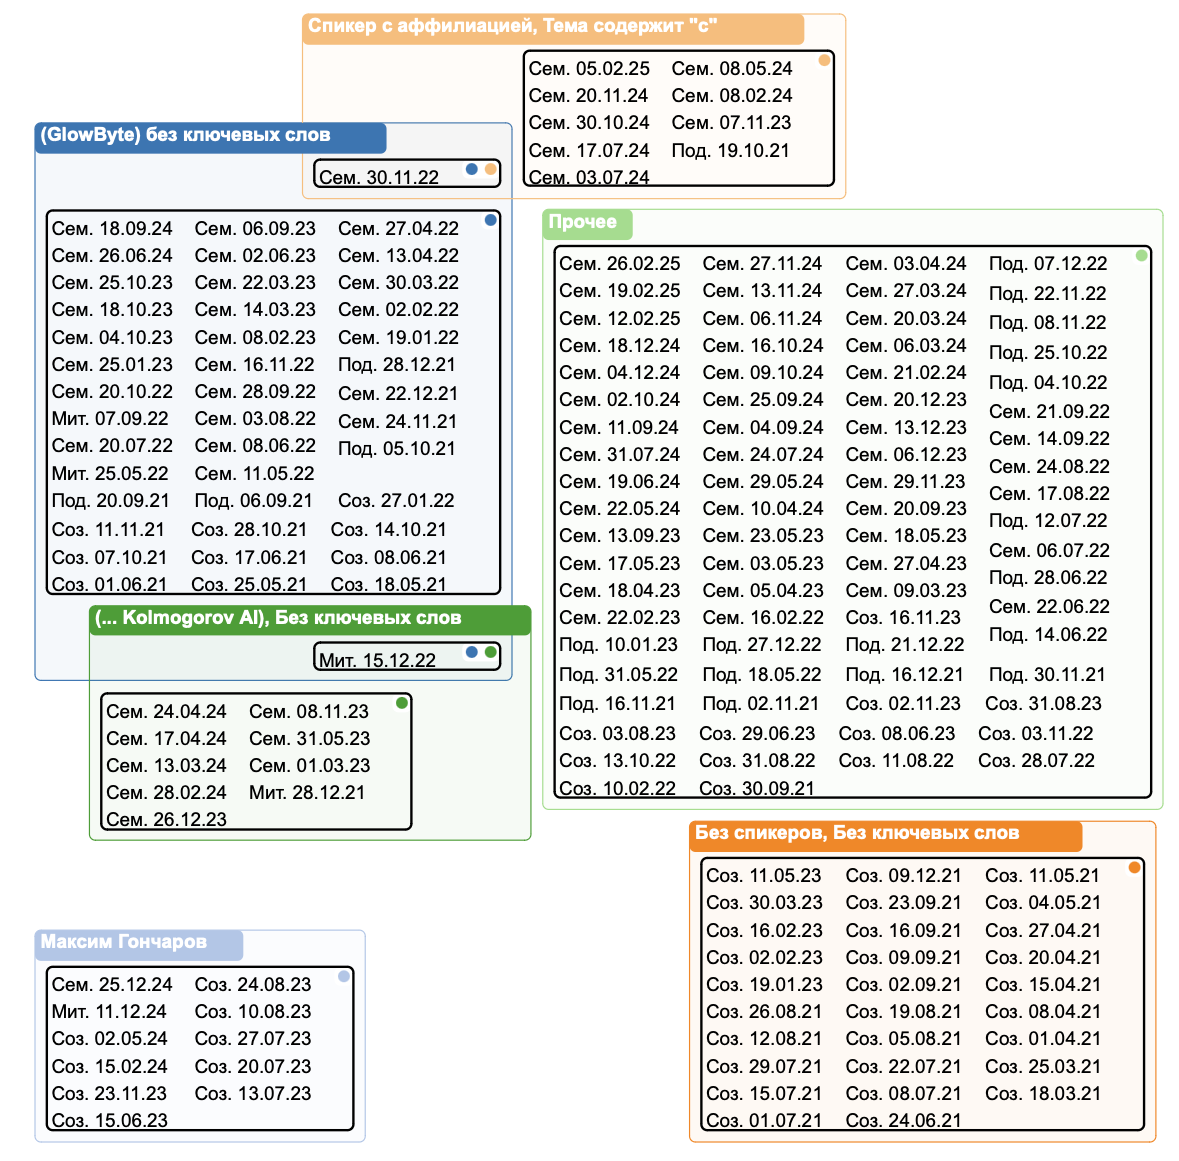

# Bonus. Short descriptions of clusters

Описания кластеров, выдаваемые функцией `ps.mine_concepts` - это максимально точные описания кластеров.

Это хорошо, потому что для каждого кластера существует лишь один максимально точный паттерн и его обычно легко расчитать.

И это плохо, потому что иногда максимально точный паттен бывает слишком точным, настолько, что его может быть сложно прочитать и осознать.

В этом случае, для каждого паттерна можно поискать "ключи" (eng. keys) - минимальные паттерны, описывающие совершенно те же объекты, что и данный максимальный паттерн. Часто, на один максимальный паттерн находится несколько минимальных паттернов. К тому же, расчёт ключей может занять какое-то время.

В литературе, ключи также могут упоминаться как "минимальные генераторы", или просто "генераторы". Схожие термины из теорий ипмликаций и SAT: "собственные посылки", или как "простые импликанты".

In [50]:
intent = concepts3[2][1]
keys = list(ps.iter_keys(intent))

print('intent', intent)
for key in keys:
    print('key', key)
print([len(k) for k in keys], len(intent))

intent {'Спикеры': {'(', ')'}}
key {'Спикеры': {')'}}
key {'Спикеры': {'('}}
[1, 1] 2


In [51]:
intent = concepts3[-1][1]
keys = list(ps.iter_keys(intent))

print('intent', intent)
for key in keys:
    print('key', key)
print([len(k) for k in keys], len(intent))

intent {'Ключевые слова': {'<Unknown>'}, 'Тема': {'ML'}}
key {'Ключевые слова': {'<Unknown>'}, 'Тема': {'ML'}}
[2] 2


In [52]:
intent = concepts3[10][1]
# Если ключ ищется слишком долго, можно ограничить его "длину" (кол-во бинарных условий необходимых для описания ключа)
# Тогда, если короткого ключа не существует, то алгоритм просто ничего не вернёт
keys = list(ps.iter_keys(intent, max_length=4))

print('intent', intent)
for key in keys:
    print('key', key)
print([len(k) for k in keys], len(intent))

intent {'Спикеры': {'( GlowByte )'}}
key {'Спикеры': {'( GlowByte', 'GlowByte )'}}
[2] 1


Если найти ключ будет слишком сложно, можно попробовать найти подгруппы (eng. subgroups), примерно описывающие объекты заданного кластера.

Этот же функционал подгрупп можно использовать для интерпретируемой "символьной" классификации

In [53]:
extent, intent = concepts3[-1]
subgroups = list(ps.iter_subgroups(extent, quality_measure='F1', quality_threshold=0.95, max_length=4))

print('intent', intent)
for subgroup, subgroup_extent, stats in subgroups:
    print(f"{subgroup=}")
    print(f"quality measure: {stats:.2%}")
    print('')

intent {'Ключевые слова': {'<Unknown>'}, 'Тема': {'ML'}}
subgroup={'Тема': {'ML'}}
quality measure: 95.24%

